In [ ]:
import pandas as pd

df = pd.read_csv(
    "data_banknote_authentication.txt",
    header=None
)

In [ ]:
import os

SAVE_DIR = "/content/Lab_Figures"

os.makedirs(SAVE_DIR, exist_ok=True)

print("Figures will be saved in:", SAVE_DIR)

Figures will be saved in: /content/Lab_Figures


In [ ]:
def save_plot(filename):
    """
    Save the current matplotlib figure in EPS format
    with 700 DPI.
    """
    plt.savefig(
        os.path.join(SAVE_DIR, filename + ".eps"),
        format="eps",
        dpi=600,
        bbox_inches="tight"
    )

    print(f"Saved: {filename}.eps")

In [ ]:
import pandas as pd

column_names = [
    "Variance",
    "Skewness",
    "Kurtosis",
    "Entropy",
    "Class"
]

df = pd.read_csv(
    "data_banknote_authentication.txt",
    header=None,
    names=column_names
)

df.head()

,Variance,Skewness,Kurtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Kurtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [ ]:
df.head()

,Variance,Skewness,Kurtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
df.isnull().sum()

,0
Variance,0
Skewness,0
Kurtosis,0
Entropy,0
Class,0


In [ ]:
df.describe()

,Variance,Skewness,Kurtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look better
sns.set(style="whitegrid")

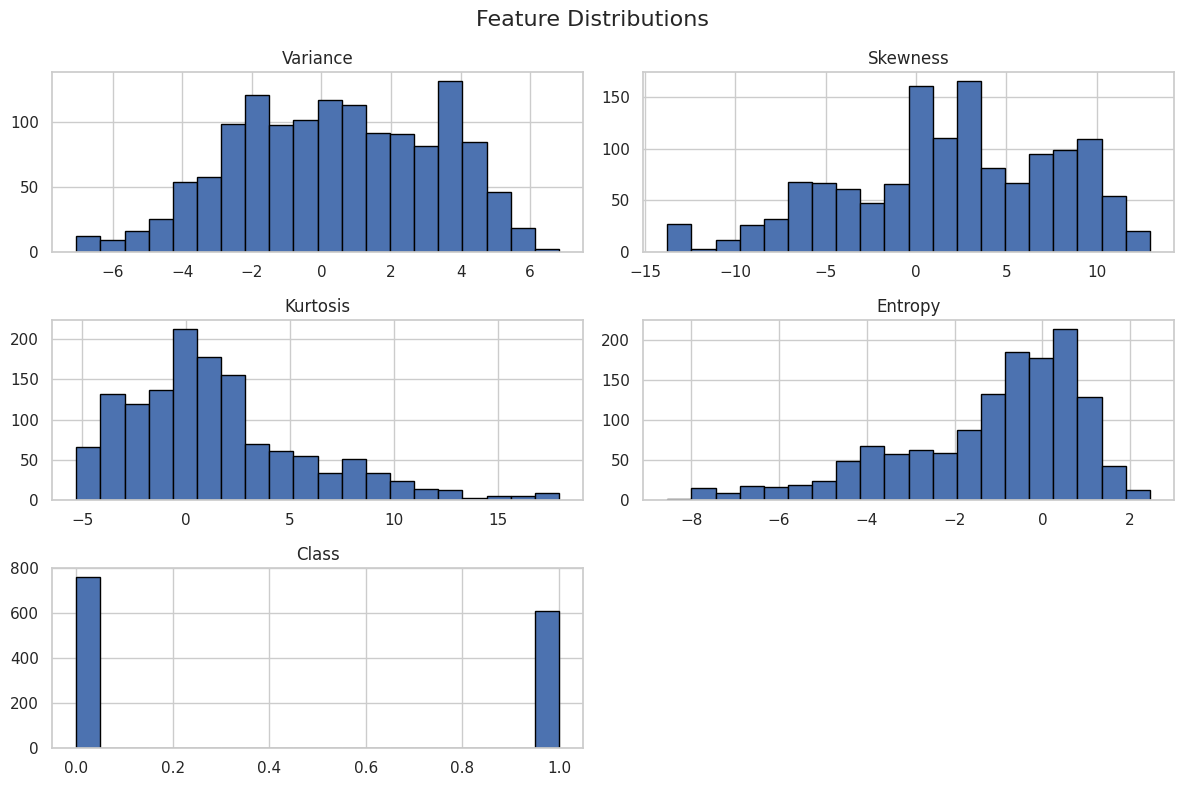

In [ ]:
df.hist(figsize=(12,8), bins=20, edgecolor='black')

plt.suptitle("Feature Distributions", fontsize=16)

plt.tight_layout()



plt.show()


Saved: 01_Feature_Histograms.eps


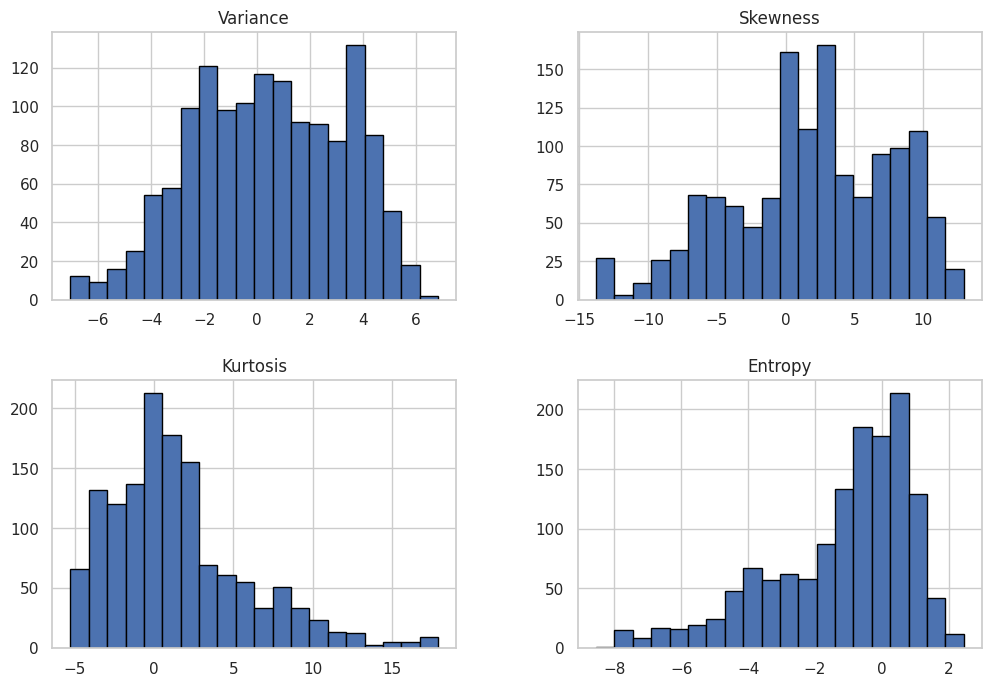

In [ ]:
df.iloc[:, :-1].hist(figsize=(12, 8), bins=20, edgecolor='black')
save_plot("01_Feature_Histograms")


Saved: 02_Correlation_Heatmap.eps


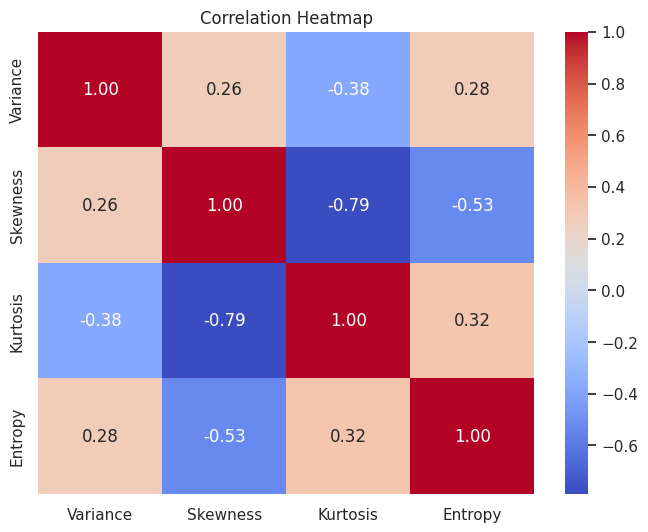

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.iloc[:, :-1].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
save_plot("02_Correlation_Heatmap")
plt.show()

Saved: 03_Scatter_Plot.eps


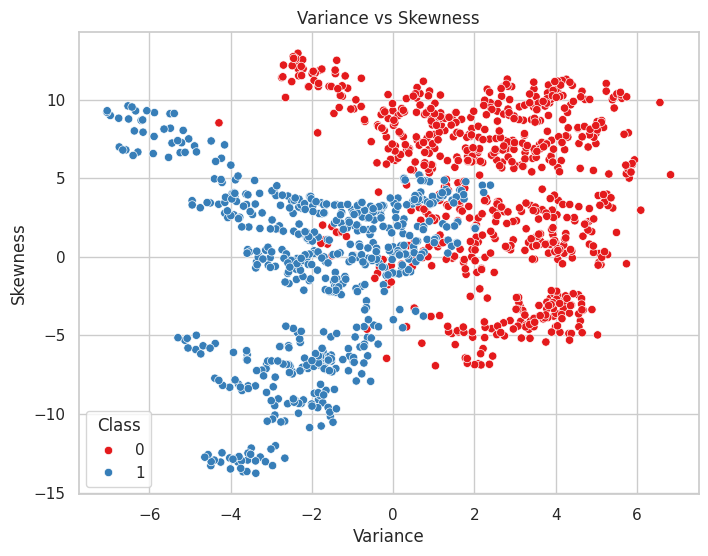

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Variance",
    y="Skewness",
    hue="Class",
    palette="Set1"
)

plt.title("Variance vs Skewness")
save_plot("03_Scatter_Plot")
plt.show()

Saved: 04_Boxplot.eps


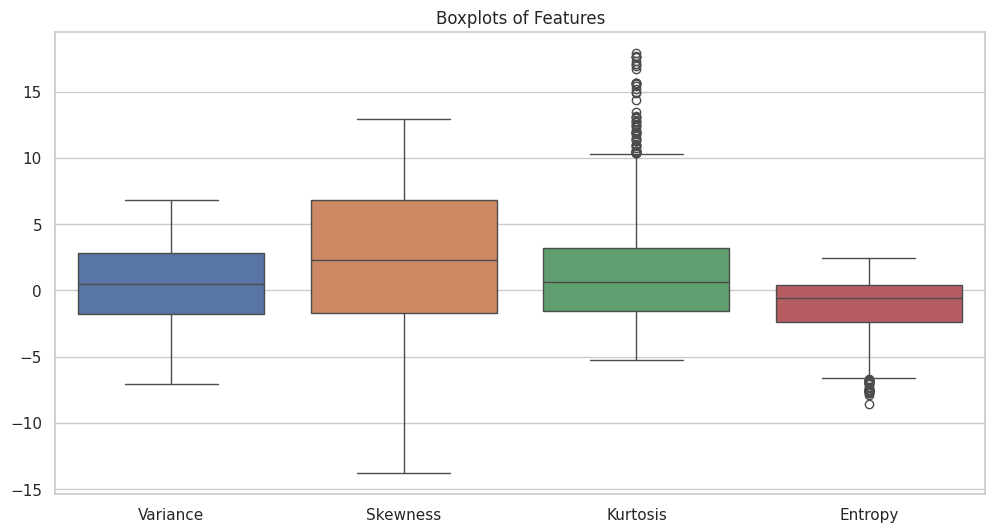

In [ ]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df.iloc[:, :-1])

plt.title("Boxplots of Features")
save_plot("04_Boxplot")
plt.show()

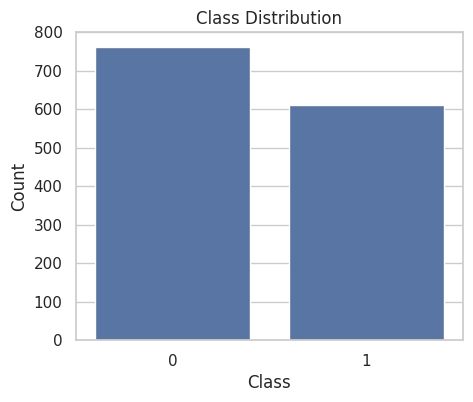

In [ ]:
plt.figure(figsize=(5, 4))

sns.countplot(data=df, x="Class")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [ ]:
# Features (Input)
X = df.iloc[:, :-1]

# Target (Output)
y = df.iloc[:, -1]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Variance  Skewness  Kurtosis  Entropy
0   3.62160    8.6661   -2.8073 -0.44699
1   4.54590    8.1674   -2.4586 -1.46210
2   3.86600   -2.6383    1.9242  0.10645
3   3.45660    9.5228   -4.0112 -3.59440
4   0.32924   -4.4552    4.5718 -0.98880

Target:
0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
import pandas as pd

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,Variance,Skewness,Kurtosis,Entropy
0,1.121806,1.149455,-0.975970,0.354561
1,1.447066,1.064453,-0.895036,-0.128767
2,1.207810,-0.777352,0.122218,0.618073
3,1.063742,1.295478,-1.255397,-1.144029
4,-0.036772,-1.087038,0.736730,0.096587


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (1097, 4)
Testing Features: (275, 4)
Training Labels: (1097,)
Testing Labels: (275,)


In [ ]:
import numpy as np

class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=100):

        self.learning_rate = learning_rate
        self.epochs = epochs

        self.weights = None
        self.bias = None

        self.errors = []
        self.weight_history = []
        self.bias_history = []

    # Step Activation Function
    def activation(self, z):
        return 1 if z >= 0 else 0

    # Training Function
    def fit(self, X, y):

        # Convert to NumPy arrays
        X = np.array(X)
        y = np.array(y)

        n_samples, n_features = X.shape

        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):

            errors = 0

            for i in range(n_samples):

                # Weighted Sum
                z = np.dot(X[i], self.weights) + self.bias

                # Prediction
                y_pred = self.activation(z)

                # Error
                error = y[i] - y_pred

                # Update weights
                self.weights += self.learning_rate * error * X[i]

                # Update bias
                self.bias += self.learning_rate * error

                if error != 0:
                    errors += 1

            self.errors.append(errors)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            print(f"Epoch {epoch+1}/{self.epochs} | Errors = {errors}")

    # Prediction Function
    def predict(self, X):

        X = np.array(X)

        predictions = []

        for sample in X:

            z = np.dot(sample, self.weights) + self.bias

            predictions.append(self.activation(z))

        return np.array(predictions)

In [ ]:
# Create model
model = Perceptron(
    learning_rate=0.01,
    epochs=100
)

# Train
model.fit(X_train, y_train)

Epoch 1/100 | Errors = 47
Epoch 2/100 | Errors = 26
Epoch 3/100 | Errors = 34
Epoch 4/100 | Errors = 23
Epoch 5/100 | Errors = 27
Epoch 6/100 | Errors = 25
Epoch 7/100 | Errors = 19
Epoch 8/100 | Errors = 19
Epoch 9/100 | Errors = 16
Epoch 10/100 | Errors = 26
Epoch 11/100 | Errors = 25
Epoch 12/100 | Errors = 26
Epoch 13/100 | Errors = 21
Epoch 14/100 | Errors = 21
Epoch 15/100 | Errors = 22
Epoch 16/100 | Errors = 16
Epoch 17/100 | Errors = 17
Epoch 18/100 | Errors = 15
Epoch 19/100 | Errors = 15
Epoch 20/100 | Errors = 17
Epoch 21/100 | Errors = 14
Epoch 22/100 | Errors = 15
Epoch 23/100 | Errors = 21
Epoch 24/100 | Errors = 17
Epoch 25/100 | Errors = 19
Epoch 26/100 | Errors = 19
Epoch 27/100 | Errors = 18
Epoch 28/100 | Errors = 19
Epoch 29/100 | Errors = 17
Epoch 30/100 | Errors = 18
Epoch 31/100 | Errors = 17
Epoch 32/100 | Errors = 21
Epoch 33/100 | Errors = 19
Epoch 34/100 | Errors = 15
Epoch 35/100 | Errors = 18
Epoch 36/100 | Errors = 16
Epoch 37/100 | Errors = 14
Epoch 38/1

In [ ]:
y_pred = model.predict(X_test)

Accuracy : 0.9854545454545455
Precision: 0.984251968503937
Recall   : 0.984251968503937
F1 Score : 0.984251968503937

Confusion Matrix:
[[146   2]
 [  2 125]]
Saved: 05_Confusion_Matrix.eps


<Figure size 600x600 with 0 Axes>

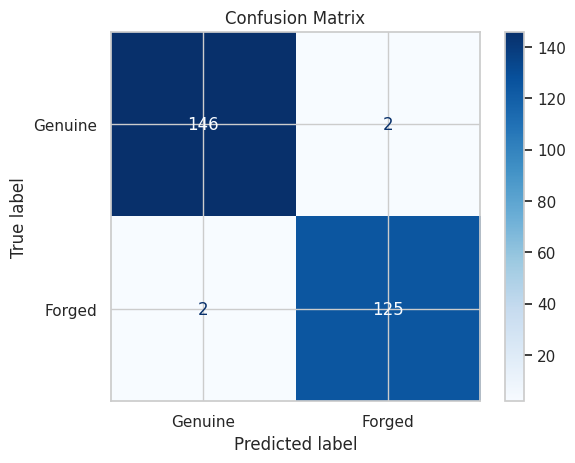

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine", "Forged"]
)

plt.figure(figsize=(6,6))
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix")
save_plot("05_Confusion_Matrix")
plt.show()

Saved: 06_Training_Error.eps


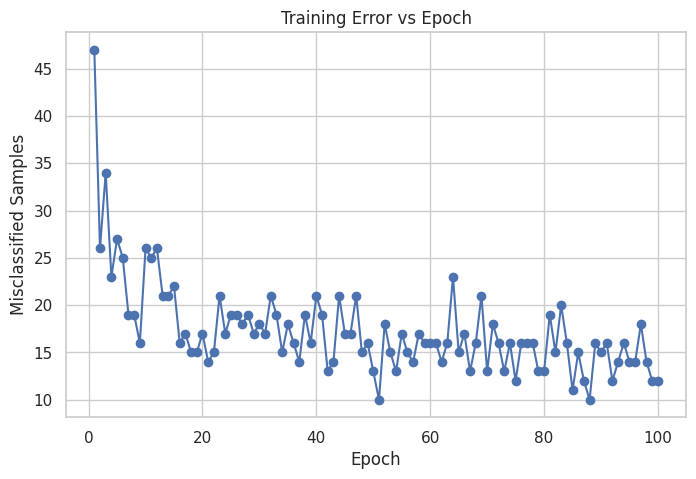

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, model.epochs+1),
    model.errors,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Training Error vs Epoch")

save_plot("06_Training_Error")

plt.grid(True)
plt.show()

Saved: 07_Bias_Evolution.eps


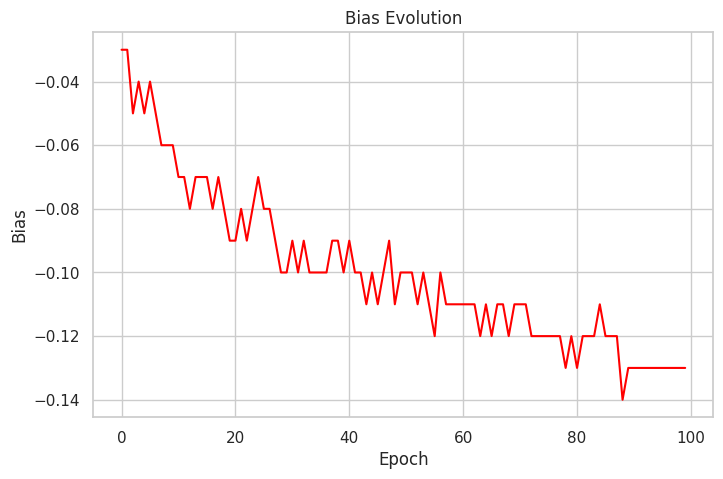

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(model.bias_history, color='red')

plt.xlabel("Epoch")
plt.ylabel("Bias")
plt.title("Bias Evolution")

save_plot("07_Bias_Evolution")

plt.grid(True)
plt.show()

Saved: 07_Weight_Evolution.eps


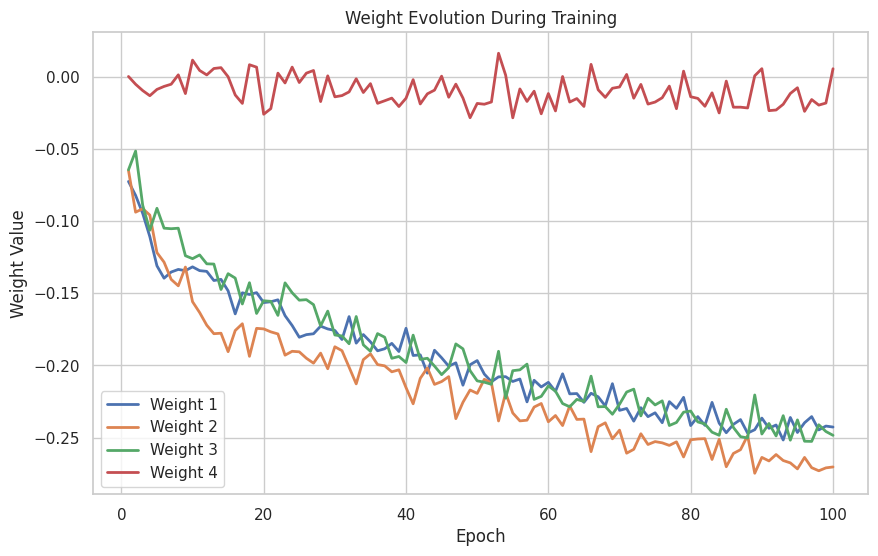

In [ ]:
# Convert weight history to NumPy array
weights = np.array(model.weight_history)

plt.figure(figsize=(10,6))

# Plot each weight across epochs
for i in range(weights.shape[1]):
    plt.plot(
        range(1, model.epochs + 1),
        weights[:, i],
        linewidth=2,
        label=f"Weight {i+1}"
    )

plt.title("Weight Evolution During Training")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend()
plt.grid(True)

save_plot("07_Weight_Evolution")

plt.show()

Epoch 1/100 | Errors = 47
Epoch 2/100 | Errors = 26
Epoch 3/100 | Errors = 34
Epoch 4/100 | Errors = 23
Epoch 5/100 | Errors = 27
Epoch 6/100 | Errors = 25
Epoch 7/100 | Errors = 19
Epoch 8/100 | Errors = 19
Epoch 9/100 | Errors = 16
Epoch 10/100 | Errors = 26
Epoch 11/100 | Errors = 25
Epoch 12/100 | Errors = 26
Epoch 13/100 | Errors = 21
Epoch 14/100 | Errors = 21
Epoch 15/100 | Errors = 22
Epoch 16/100 | Errors = 16
Epoch 17/100 | Errors = 17
Epoch 18/100 | Errors = 15
Epoch 19/100 | Errors = 15
Epoch 20/100 | Errors = 17
Epoch 21/100 | Errors = 14
Epoch 22/100 | Errors = 15
Epoch 23/100 | Errors = 21
Epoch 24/100 | Errors = 17
Epoch 25/100 | Errors = 19
Epoch 26/100 | Errors = 19
Epoch 27/100 | Errors = 18
Epoch 28/100 | Errors = 19
Epoch 29/100 | Errors = 17
Epoch 30/100 | Errors = 18
Epoch 31/100 | Errors = 17
Epoch 32/100 | Errors = 21
Epoch 33/100 | Errors = 19
Epoch 34/100 | Errors = 15
Epoch 35/100 | Errors = 18
Epoch 36/100 | Errors = 16
Epoch 37/100 | Errors = 14
Epoch 38/1

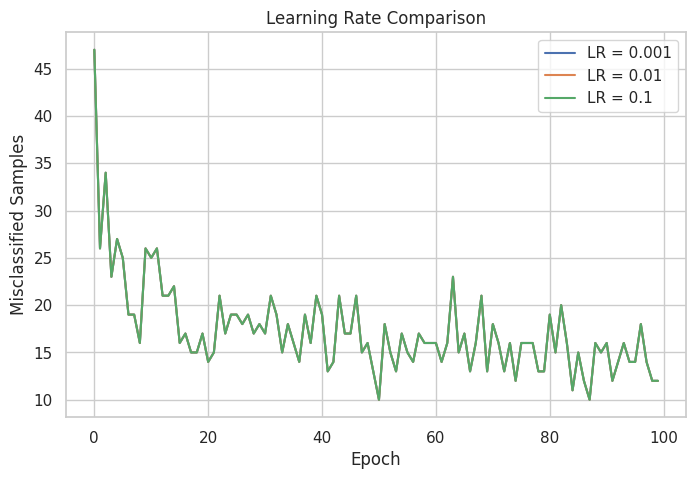

In [ ]:
learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(8,5))

for lr in learning_rates:

    temp_model = Perceptron(
        learning_rate=lr,
        epochs=100
    )

    temp_model.fit(X_train, y_train)

    plt.plot(
        temp_model.errors,
        label=f"LR = {lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Learning Rate Comparison")


save_plot("09_Learning_Rate_Comparison")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("Dataset Size :", len(df))
print("Train/Test Split : 80/20")
print("Learning Rate :", model.learning_rate)
print("Epochs :", model.epochs)
print("Final Weights :", model.weights)
print("Final Bias :", model.bias)
print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Dataset Size : 1372
Train/Test Split : 80/20
Learning Rate : 0.01
Epochs : 100
Final Weights : [-0.24265839 -0.27029473 -0.24839525  0.00557345]
Final Bias : -0.12999999999999998
Accuracy : 0.9854545454545455
Precision : 0.984251968503937
Recall : 0.984251968503937
F1 Score : 0.984251968503937


In [ ]:
import shutil

shutil.make_archive(
    "/content/Lab_Figures",
    'zip',
    SAVE_DIR
)

print("ZIP file created successfully!")

ZIP file created successfully!


In [ ]:
from google.colab import files

files.download("/content/Lab_Figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

training_summary = pd.DataFrame({
    "Parameter": [
        "Dataset Size",
        "Train/Test Split",
        "Learning Rate",
        "Epochs",
        "Final Weights",
        "Final Bias",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Value": [
        len(df),
        "80 : 20",
        model.learning_rate,
        model.epochs,
        np.round(model.weights, 4),
        round(model.bias, 4),
        round(accuracy, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4)
    ]
})

training_summary

,Parameter,Value
0,Dataset Size,1372
1,Train/Test Split,80 : 20
2,Learning Rate,0.01
3,Epochs,100
4,Final Weights,"[-0.2427, -0.2703, -0.2484, 0.0056]"
5,Final Bias,-0.13
6,Accuracy,0.9855
7,Precision,0.9843
8,Recall,0.9843
9,F1-score,0.9843


In [ ]:
epoch_table = pd.DataFrame({
    "Epoch": range(1, model.epochs + 1),
    "Errors": model.errors,
    "Weight 1": [round(w[0], 4) for w in model.weight_history],
    "Weight 2": [round(w[1], 4) for w in model.weight_history],
    "Weight 3": [round(w[2], 4) for w in model.weight_history],
    "Weight 4": [round(w[3], 4) for w in model.weight_history],
    "Bias": [round(b, 4) for b in model.bias_history]
})

# Display the first 20 epochs
epoch_table_20 = epoch_table.head(20)

epoch_table_20

,Epoch,Errors,Weight 1,Weight 2,Weight 3,Weight 4,Bias
0,1,47,-0.0725,-0.0649,-0.0645,0.0002,-0.03
1,2,26,-0.0822,-0.0938,-0.0515,-0.0052,-0.03
2,3,34,-0.0947,-0.0914,-0.0891,-0.0096,-0.05
3,4,23,-0.1107,-0.0958,-0.1063,-0.0131,-0.04
4,5,27,-0.1310,-0.1218,-0.0911,-0.0088,-0.05
5,6,25,-0.1395,-0.1284,-0.1049,-0.0067,-0.04
6,7,19,-0.1353,-0.1404,-0.1053,-0.0052,-0.05
7,8,19,-0.1335,-0.1448,-0.1049,0.0013,-0.06
8,9,16,-0.1343,-0.1318,-0.1240,-0.0116,-0.06
9,10,26,-0.1317,-0.1558,-0.1260,0.0115,-0.06
